In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\jabee\OneDrive\Desktop\projects\fake_job_detection\data\fake_job_postings.csv")

# Data understanding

In [3]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [6]:
df.shape

(17880, 18)

In [7]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [10]:
df.isnull().sum().sort_values(ascending=False)

salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
title                      0
fraudulent                 0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [12]:
df['fraudulent'].value_counts(normalize=True)*100

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

In [13]:
pd.crosstab(
    df['has_company_logo'],
    df['fraudulent']
)

fraudulent,0,1
has_company_logo,,
0,3077,583
1,13937,283


In [14]:
pd.crosstab(
    df['has_company_logo'],
    df['fraudulent'],
    normalize='index'
)*100

fraudulent,0,1
has_company_logo,,
0,84.071038,15.928962
1,98.009845,1.990155


In [15]:
pd.crosstab(
    df['has_questions'],
    df['fraudulent']
)

fraudulent,0,1
has_questions,,
0,8472,616
1,8542,250


In [16]:
pd.crosstab(
    df['has_questions'],
    df['fraudulent'],
    normalize='index'
)*100

fraudulent,0,1
has_questions,,
0,93.221831,6.778169
1,97.156506,2.843494


In [17]:
pd.crosstab(
    df['telecommuting'],
    df['fraudulent']
)

fraudulent,0,1
telecommuting,,
0,16311,802
1,703,64


In [18]:
pd.crosstab(
    df['telecommuting'],
    df['fraudulent'],
    normalize='index'
)*100

fraudulent,0,1
telecommuting,,
0,95.313504,4.686496
1,91.655802,8.344198


In [19]:
df['employment_type'].value_counts()

employment_type
Full-time    11620
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

In [20]:
df['required_education'].value_counts()

required_education
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Doctorate                              26
Vocational - HS Diploma                 9
Vocational - Degree                     6
Name: count, dtype: int64

In [21]:
df['required_experience'].value_counts()

required_experience
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

In [22]:
df['industry'].value_counts().head(15)

industry
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
Financial Services                      779
Hospital & Health Care                  497
Consumer Services                       358
Telecommunications                      342
Oil & Energy                            287
Retail                                  223
Real Estate                             175
Accounting                              159
Construction                            158
E-Learning                              139
Name: count, dtype: int64

In [23]:
pd.crosstab(
    df['required_education'],
    df['fraudulent'],
    normalize='index'
)*100

fraudulent,0,1
required_education,,
Associate Degree,97.810219,2.189781
Bachelor's Degree,98.056365,1.943635
Certification,88.823529,11.176471
Doctorate,96.153846,3.846154
High School or equivalent,91.826923,8.173077
Master's Degree,92.548077,7.451923
Professional,94.594595,5.405405
Some College Coursework Completed,97.058824,2.941176
Some High School Coursework,25.925926,74.074074


In [24]:
pd.crosstab(
    df['required_experience'],
    df['fraudulent'],
    normalize='index'
)*100

fraudulent,0,1
required_experience,,
Associate,98.171528,1.828472
Director,95.629820,4.370180
Entry level,93.362996,6.637004
Executive,92.907801,7.092199
Internship,97.375328,2.624672
Mid-Senior level,97.033342,2.966658
Not Applicable,94.623656,5.376344


In [25]:
pd.crosstab(
    df['employment_type'],
    df['fraudulent'],
    normalize='index'
)*100

fraudulent,0,1
employment_type,,
Contract,97.112861,2.887139
Full-time,95.783133,4.216867
Other,93.392070,6.607930
Part-time,90.715182,9.284818
Temporary,99.170124,0.829876


In [26]:
df_clean=df.copy()

In [27]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [29]:
df.drop('job_id',axis=1,inplace=True)

In [30]:
df.columns

Index(['title', 'location', 'department', 'salary_range', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [31]:
df.fillna("",inplace=True)

In [32]:
df.isnull().sum()

title                  0
location               0
department             0
salary_range           0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

In [33]:
df['combined']=(
    df['title'].astype(str) + " " +
    df['company_profile'].astype(str) + " " +
    df['description'].astype(str) + " " +
    df['requirements'].astype(str) + " " +
    df['benefits'].astype(str)
)

In [35]:
df['combined'].head()

0    Marketing Intern We're Food52, and we've creat...
1    Customer Service - Cloud Video Production 90 S...
2    Commissioning Machinery Assistant (CMA) Valor ...
3    Account Executive - Washington DC Our passion ...
4    Bill Review Manager SpotSource Solutions LLC i...
Name: combined, dtype: object

In [36]:
y = df['fraudulent']

In [41]:
X_text=df['combined']

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [39]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

In [42]:
X = tfidf.fit_transform(X_text)

In [43]:
X.shape

(17880, 5000)

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(14304, 5000)
(3576, 5000)
fraudulent
0    13611
1      693
Name: count, dtype: int64
fraudulent
0    3403
1     173
Name: count, dtype: int64


In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [49]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [50]:
y_pred = rf.predict(X_test)

In [51]:
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9801454138702461


In [52]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3403    0]
 [  71  102]]


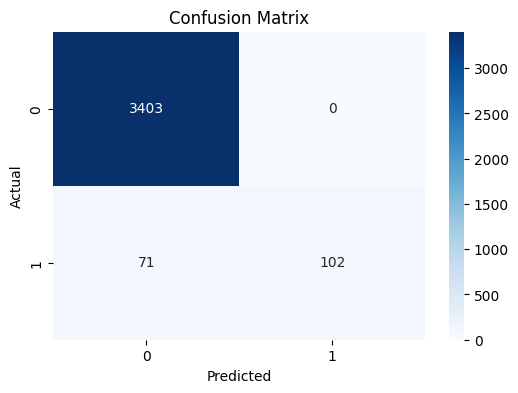

In [53]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [54]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       1.00      0.59      0.74       173

    accuracy                           0.98      3576
   macro avg       0.99      0.79      0.87      3576
weighted avg       0.98      0.98      0.98      3576



In [57]:
feature_importance = pd.DataFrame({
    'feature': tfidf.get_feature_names_out(),
    'importance': rf.feature_importances_
})

In [58]:
feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

In [61]:
import re

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [63]:
df['combined'] = df['combined'].apply(clean_text)

In [65]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = tfidf.fit_transform(df['combined'])

In [69]:
feature_importance.head(50)

,feature,importance
4721,url_0fa3f7c5e23a16de16a841e368006cae916884407d...,0.013773
1602,entry,0.010318
4550,time,0.008453
188,administrative,0.007859
1460,earn,0.006405
263,aker,0.006063
4118,signing,0.005805
3712,refined,0.005592
2182,hse,0.005312
837,clerical,0.004896


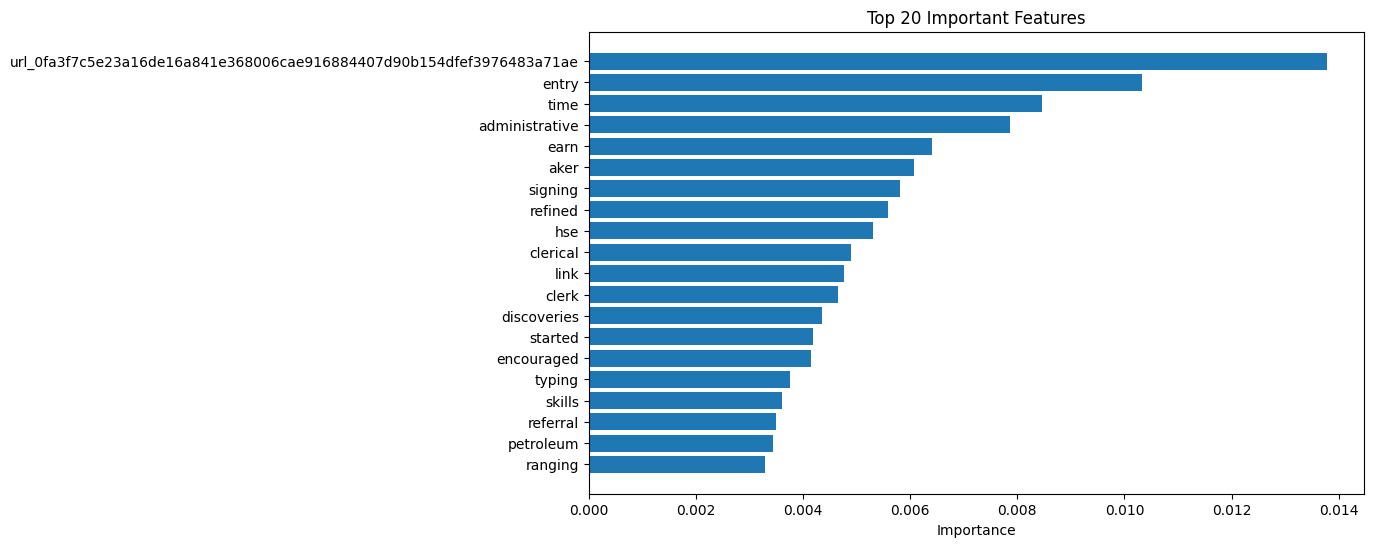

In [60]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20['feature'],
    top20['importance']
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.xlabel("Importance")

plt.show()

In [70]:
feature_importance['feature'].str.startswith('url_').sum()

18